In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df_aud = pd.read_csv('audience.csv')

In [13]:
df_aud['date'] = pd.to_datetime(df_aud['date'])

df_aud.head()

,date,user_id,view_adverts
0,2023-11-11,8c020470-8461-11ed-83d0-552e8cc749d6,13
1,2023-11-18,5875f070-7b92-11ee-a6fb-8b298e83f4f7,14
2,2023-11-29,3c2d27c0-4fd6-11eb-b89f-2ffb31b67dd6,21
3,2023-11-29,234a96d0-ad16-11ed-a2e6-793ddfeeba1f,23
4,2023-11-29,4d07c180-644f-11eb-879c-b7c02edf4f37,12


In [14]:
df_ab = pd.read_csv('ab_tests.csv')

df_ab.head()

,experiment_num,experiment_group,user_id,revenue
0,1,test,38456,520
1,1,control,13125924,806
2,1,control,9761984,0
3,1,test,11387012,208
4,1,test,18319648,104


In [5]:
df_listers = pd.read_csv('listers.csv')

In [15]:
df_listers['date'] = pd.to_datetime(df_listers['date'])

df_listers.head()

,user_id,date,cnt_adverts,age,cnt_contacts,revenue
0,100,2022-01-01,6,21,119,53
1,100,2022-01-02,2,21,200,18
2,100,2022-01-03,6,21,193,42
3,100,2022-01-04,2,21,143,38
4,100,2022-01-05,2,21,190,40


In [ ]:
#7. Чему будет равен NPS

In [20]:
total_users = 2000
promoters = 1200
detractors = 500

In [21]:
promoters_percent = (promoters / total_users) * 100
detractors_percent = (detractors / total_users) * 100

nps = promoters_percent - detractors_percent

print(f"Доля сторонников: {promoters_percent}%")
print(f"Доля критиков: {detractors_percent}%")
print(f"Ответ: NPS = {nps}%")

Доля сторонников: 60.0%
Доля критиков: 25.0%
Ответ: NPS = 35.0%


In [ ]:
#8. Данные АБ-тестов

In [16]:
df_ab = pd.read_csv('ab_tests.csv')

for exp_num in df_ab['experiment_num'].unique():
    exp_data = df_ab[df_ab['experiment_num'] == exp_num]
    
    control_group = exp_data[exp_data['experiment_group'] == 'control']['revenue']
    test_group = exp_data[exp_data['experiment_group'] == 'test']['revenue']
    
    arpu_c = control_group.mean()
    arpu_t = test_group.mean()
    
    t_stat, p_val = stats.ttest_ind(test_group, control_group, equal_var=False)
    
    print(f"Эксперимент {exp_num}:")
    print(f"  ARPU Контроль: {arpu_c:.2f} | ARPU Тест: {arpu_t:.2f}")
    print(f"  p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("  Вывод: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. Изменения можно внедрять (если тест лучше).")
    else:
        print("  Вывод: Разница СЛУЧАЙНА. Изменения не внедряем.")
    print("-" * 50)

Эксперимент 1:
  ARPU Контроль: 722.46 | ARPU Тест: 665.74
  p-value: 0.6890
  Вывод: Разница СЛУЧАЙНА. Изменения не внедряем.
--------------------------------------------------
Эксперимент 2:
  ARPU Контроль: 704.65 | ARPU Тест: 332.93
  p-value: 0.0011
  Вывод: Разница СТАТИСТИЧЕСКИ ЗНАЧИМА. Изменения можно внедрять (если тест лучше).
--------------------------------------------------
Эксперимент 3:
  ARPU Контроль: 663.21 | ARPU Тест: 998.67
  p-value: 0.0603
  Вывод: Разница СЛУЧАЙНА. Изменения не внедряем.
--------------------------------------------------


In [ ]:
#10. По датасету с листерами посчитайте медиану возраста пользователя 

In [17]:
unique_listers = df_listers.drop_duplicates(subset=['user_id'])
print(f"Задание 10. Ответ: {unique_listers['age'].median()}")

Задание 10. Ответ: 28.0


In [ ]:
#18. Кейс с конверсией в платежи (А/Б тест)

In [18]:
from statsmodels.stats.proportion import proportions_ztest
count = [1099, 1003]
nobs = [100001055, 100047501]
z_stat, p_val = proportions_ztest(count, nobs)
print(f"p-value для теста конверсии: {p_val:.4f}")

p-value для теста конверсии: 0.0353


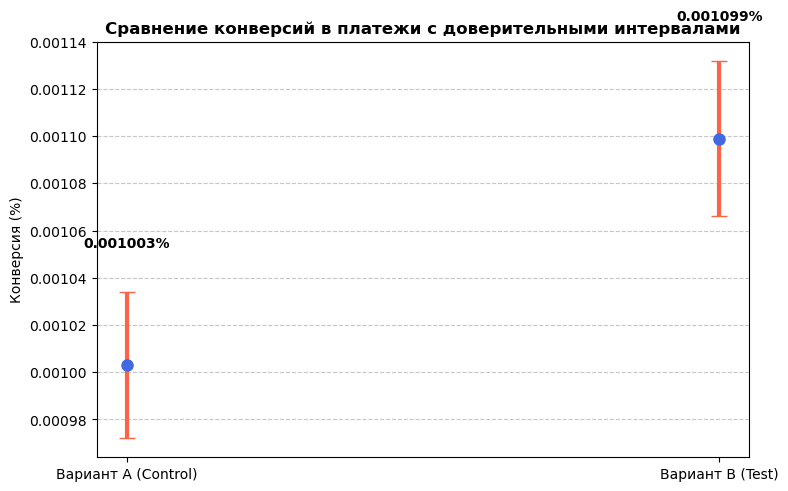

In [19]:
groups = ['Вариант A (Control)', 'Вариант B (Test)']
conversions = [0.001003, 0.001099]

errors = [0.000031, 0.000033] 

plt.figure(figsize=(8, 5))
plt.errorbar(groups, conversions, yerr=errors, fmt='o', color='royalblue', 
             ecolor='tomato', elinewidth=3, capsize=6, markersize=8)

plt.title('Сравнение конверсий в платежи с доверительными интервалами', fontsize=12, fontweight='bold')
plt.ylabel('Конверсия (%)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(conversions):
    plt.text(i, val + 0.00005, f"{val:.6f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()